# Clustering del tipo de fraude

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("datos/v6/operaciones.parquet")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1202670 entries, 0 to 1202669
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   op_id                1202670 non-null  int64  
 1   mes                  1202670 non-null  int64  
 2   canal                1202670 non-null  str    
 3   hora_bin             1202670 non-null  str    
 4   dispositivo          1202670 non-null  str    
 5   monto_log            1202670 non-null  float64
 6   terminal_risk_score  1202670 non-null  float64
 7   secuencia_24h        1202670 non-null  int64  
 8   etiquetado           1202670 non-null  bool   
 9   es_fraude            1202670 non-null  bool   
dtypes: bool(2), float64(2), int64(3), str(3)
memory usage: 102.2 MB


In [4]:
df['es_fraude'].value_counts()

es_fraude
False    1190473
True       12197
Name: count, dtype: int64

In [5]:
df_hasta_18 = df[df['mes'] <= 18]

In [6]:
# 2. Identificar columnas por tipo
cols_numericas = ["monto_log", "terminal_risk_score", "secuencia_24h"]
cols_categoricas = ["canal", "hora_bin", "dispositivo"]

# 3. Configurar el Preprocesador usando ColumnTransformer
# Esto aplica StandardScaler a las numéricas y OneHotEncoder a las categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_numericas),
        (
            "cat",
            OneHotEncoder(drop=None, sparse_output=False),
            cols_categoricas,
        ),
    ]
)

## Clustering con operaciones legitimas y fraudulentas

In [7]:
X_scaled = preprocessor.fit_transform(df_hasta_18)

# 1. Separar los índices de Fraude y No Fraude
indices_fraude = df_hasta_18[df_hasta_18["es_fraude"] == True].index.values
indices_no_fraude = df_hasta_18[df_hasta_18["es_fraude"] == False].index.values

# 2. Tomar TODOS los fraudes y una muestra generosa de no-fraudes
# Usamos 30.000 no-fraudes para que el algoritmo entienda que el "no fraude" es mayoritario,
# pero permitiendo que los 7.000 fraudes tengan el peso suficiente para armar sus propios clusters.
np.random.seed(42)
muestra_no_fraude_idx = np.random.choice(indices_no_fraude, 30000, replace=False)

# Combinamos los índices de la muestra estructural
indices_muestra_final = np.concatenate([indices_fraude, muestra_no_fraude_idx])

X_sample = X_scaled[indices_muestra_final]
labels_fraude_sample = df_hasta_18.loc[indices_muestra_final, "es_fraude"].values

# 3. Correr MiniBatchKMeans sobre esta muestra estructural
mbk = MiniBatchKMeans(n_clusters=3, batch_size=2048, random_state=42)
clusters_sample = mbk.fit_predict(X_sample)

# 4. Propagar los clusters aprendidos al 1.2 millones de filas original usando KNN
knn = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn.fit(X_sample, clusters_sample)

df_hasta_18["cluster"] = knn.predict(X_scaled)
df_fraudes = df_hasta_18[df_hasta_18['es_fraude'] == True]

In [8]:
pd.crosstab(df_hasta_18["cluster"], df_hasta_18["es_fraude"])

es_fraude,False,True
cluster,,
0,412845,80
1,456065,1721
2,23289,6239


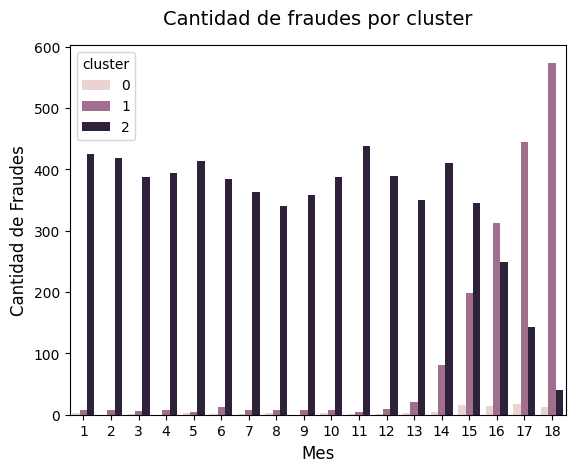

In [9]:
sns.countplot(df_fraudes, x='mes', hue='cluster')

# Personalizamos los títulos y etiquetas
plt.title("Cantidad de fraudes por cluster", fontsize=14, pad=15)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Cantidad de Fraudes", fontsize=12)

plt.show()

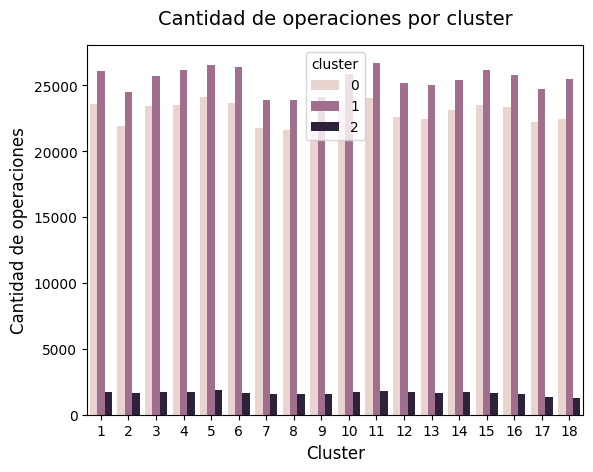

In [10]:
sns.countplot(df_hasta_18, x='mes', hue='cluster')
# Personalizamos los títulos y etiquetas
plt.title("Cantidad de operaciones por cluster", fontsize=14, pad=15)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Cantidad de operaciones", fontsize=12)
plt.show()

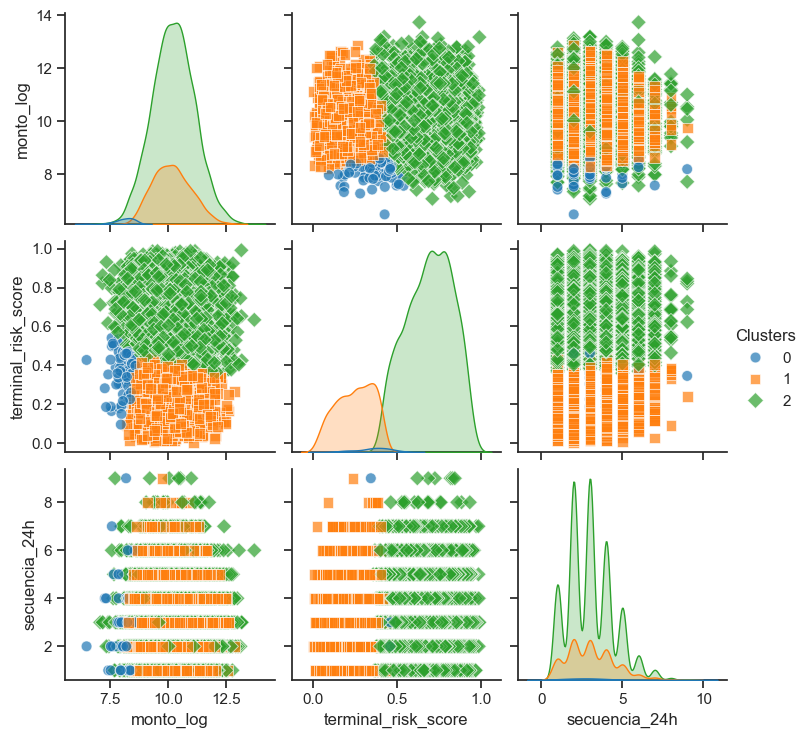

In [11]:
# 1. Configurar el estilo estético
sns.set_theme(style="ticks")

# 2. Crear el pair plot
# Seleccionamos las variables numéricas que nos interesan y la columna 'cluster'
grid = sns.pairplot(
    data=df_fraudes[cols_numericas + ["cluster"]],
    hue="cluster",  # Colorea los puntos según el cluster asignado
    palette="tab10",  # Paleta de colores bien diferenciados
    diag_kind="kde",  # Muestra curvas de densidad en la diagonal (en vez de histogramas)
    markers=["o", "s", "D"],  # Marcadores distintos para cada cluster (opcional)
    plot_kws={"alpha": 0.7, "s": 60},  # Ajustes para los scatter plots (transparencia y tamaño)
)

# 3. Personalizar un poco el título de la leyenda
grid.legend.set_title("Clusters")

# 4. Mostrar el gráfico
plt.show()

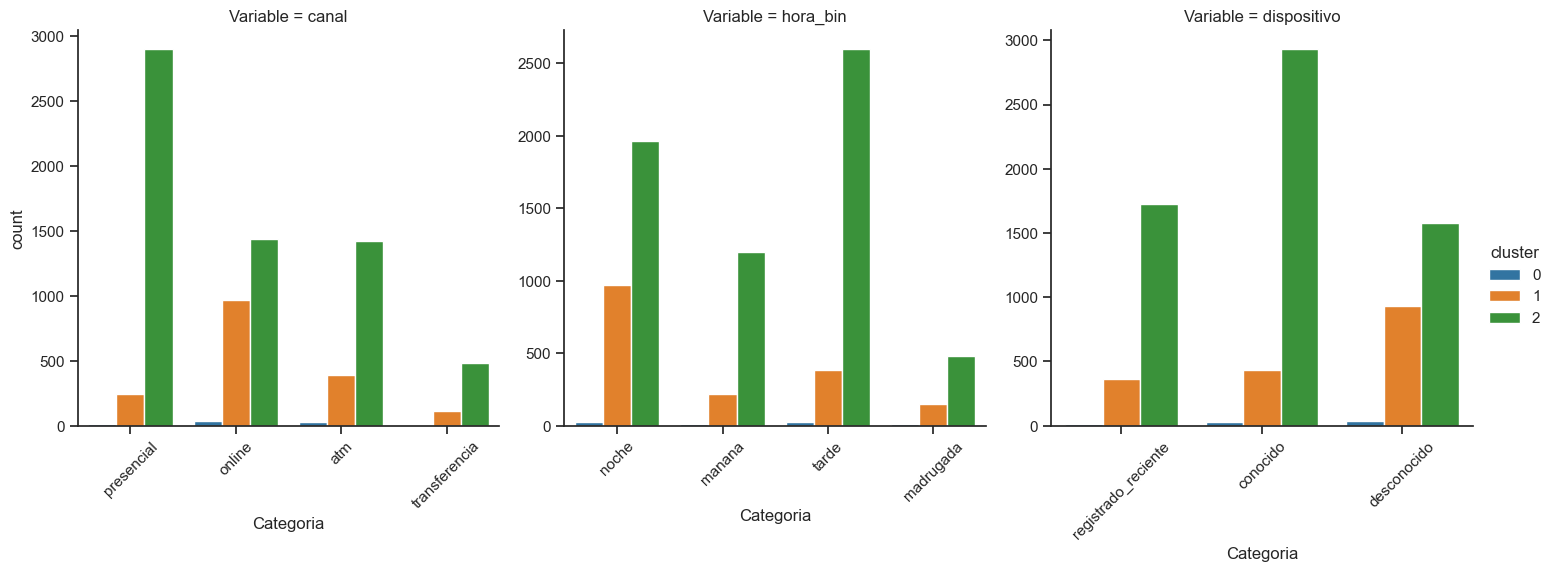

In [12]:
# Derretimos (melt) el dataframe para pasar las categóricas a filas
df_melted = pd.melt(
    df_fraudes,
    id_vars=["cluster"],
    value_vars=cols_categoricas,
    var_name="Variable",
    value_name="Categoria",
)

# Creamos la grilla facetada
g = sns.catplot(
    data=df_melted,
    x="Categoria",
    hue="cluster",
    col="Variable",
    kind="count",
    palette="tab10",
    col_wrap=3,  # Cantidad de gráficos por fila
    sharex=False,  # Clave: cada gráfico tiene sus propias categorías en el eje X
    sharey=False,
)

# Rotar las etiquetas si los nombres de las categorías son largos
g.set_xticklabels(rotation=45)
plt.show()

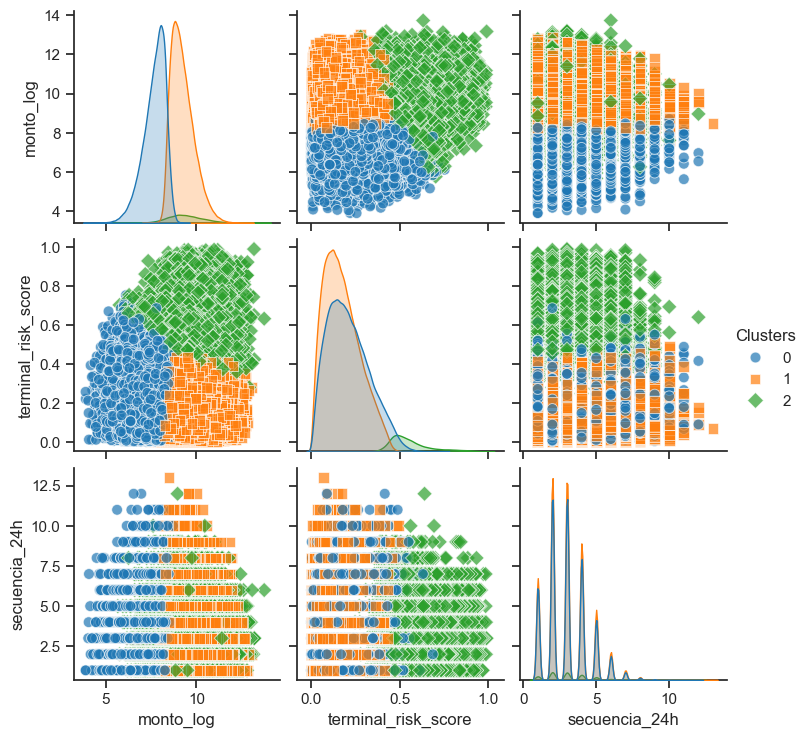

In [13]:
# 1. Configurar el estilo estético
sns.set_theme(style="ticks")

# 2. Crear el pair plot
# Seleccionamos las variables numéricas que nos interesan y la columna 'cluster'
grid = sns.pairplot(
    data=df_hasta_18[cols_numericas+ ["cluster"]],
    hue="cluster",  # Colorea los puntos según el cluster asignado
    palette="tab10",  # Paleta de colores bien diferenciados
    diag_kind="kde",  # Muestra curvas de densidad en la diagonal (en vez de histogramas)
    markers=["o", "s", "D"],  # Marcadores distintos para cada cluster (opcional)
    plot_kws={"alpha": 0.7, "s": 60},  # Ajustes para los scatter plots (transparencia y tamaño)
)

# 3. Personalizar un poco el título de la leyenda
grid.legend.set_title("Clusters")

# 4. Mostrar el gráfico
plt.show()

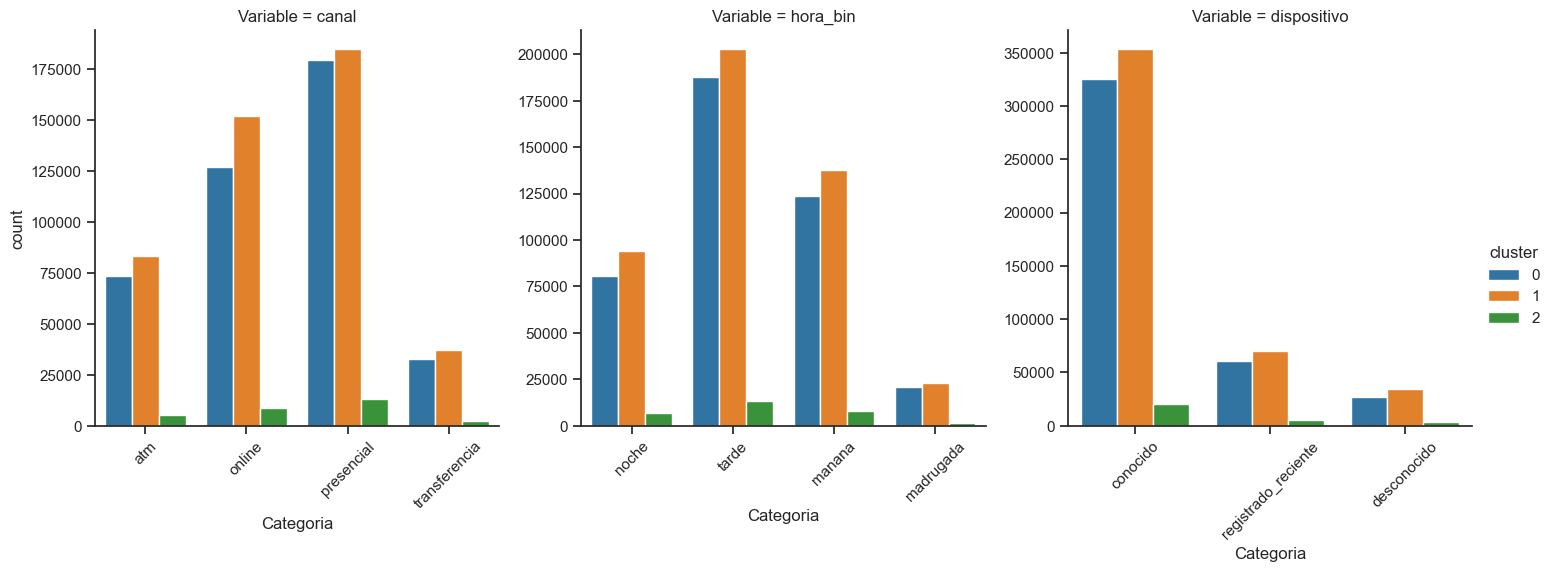

In [14]:
# Derretimos (melt) el dataframe para pasar las categóricas a filas
df_melted = pd.melt(
    df_hasta_18,
    id_vars=["cluster"],
    value_vars=cols_categoricas,
    var_name="Variable",
    value_name="Categoria",
)

# Creamos la grilla facetada
g = sns.catplot(
    data=df_melted,
    x="Categoria",
    hue="cluster",
    col="Variable",
    kind="count",
    palette="tab10",
    col_wrap=3,  # Cantidad de gráficos por fila
    sharex=False,  # Clave: cada gráfico tiene sus propias categorías en el eje X
    sharey=False,
)

# Rotar las etiquetas si los nombres de las categorías son largos
g.set_xticklabels(rotation=45)
plt.show()

## Clustering sobre fraudes

In [15]:
X_scaled = preprocessor.fit_transform(df_fraudes)

# 5. Aplicar K-Means a los datos procesados
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
kmeans.fit(X_scaled)

# 6. Guardar los resultados en el DataFrame original
df_fraudes["cluster_fraude"] = kmeans.labels_

/var/folders/8q/7djkg4_55rsgfbzr3shf6lsc0000gn/T/ipykernel_47479/3912708905.py:9: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.countplot(


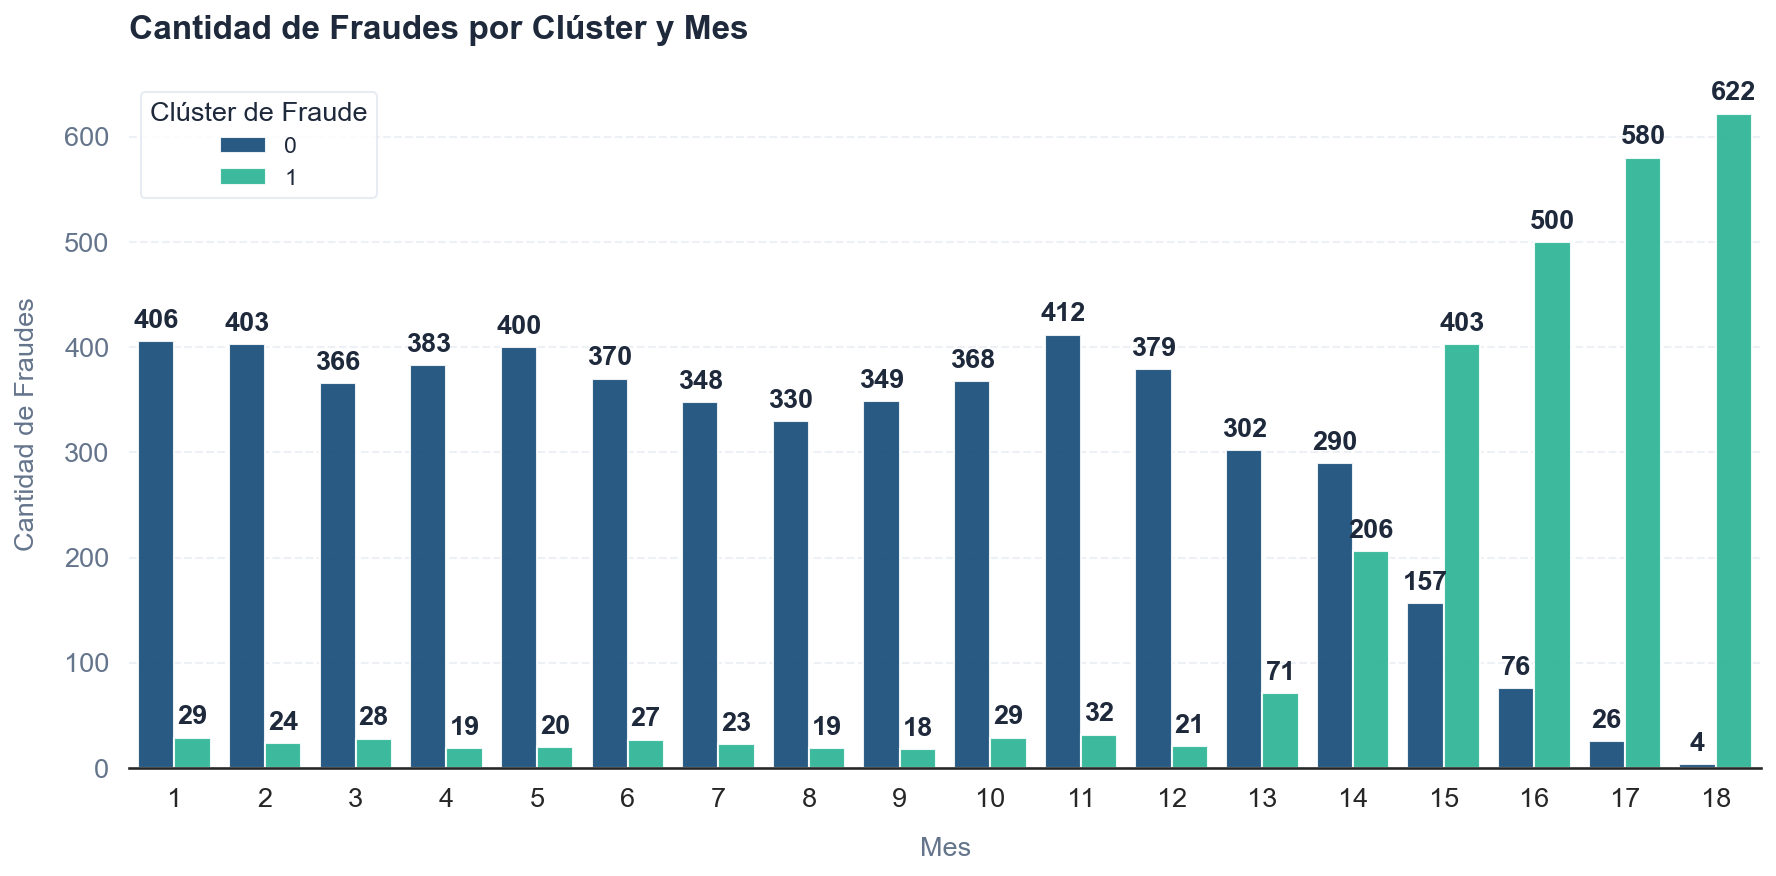

In [49]:
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["text.color"] = "#1e293b"

colores_cluster = ["#004a87", "#11caa0", "#ff823a", "#ff7171", "#bc84ee"]

plt.figure(figsize=(12, 6), dpi=150)

ax = sns.countplot(
    data=df_fraudes,
    x="mes",
    hue="cluster_fraude",
    palette=colores_cluster,
    alpha=0.9,
    edgecolor="white",
    linewidth=1,
)

ax.yaxis.grid(True, linestyle="--", alpha=0.6, color="#e2e8f0")
ax.set_axisbelow(True)

plt.title(
    "Cantidad de Fraudes por Clúster y Mes",
    fontsize=16,
    fontweight="bold",
    pad=20,
    loc="left",
)
plt.xlabel("Mes", fontsize=13, color="#64748b", labelpad=12)
plt.ylabel("Cantidad de Fraudes", fontsize=13, color="#64748b", labelpad=12)

plt.xticks(fontsize=13, fontweight="medium")
plt.yticks(fontsize=13, color="#64748b")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=13,
        color="#1e293b",
        fontweight="semibold",
    )

plt.legend(
    title="Clúster de Fraude",
    title_fontsize=13,
    fontsize=11,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0",
)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig("graficos/cl_serie_fraudes.png")
plt.show()

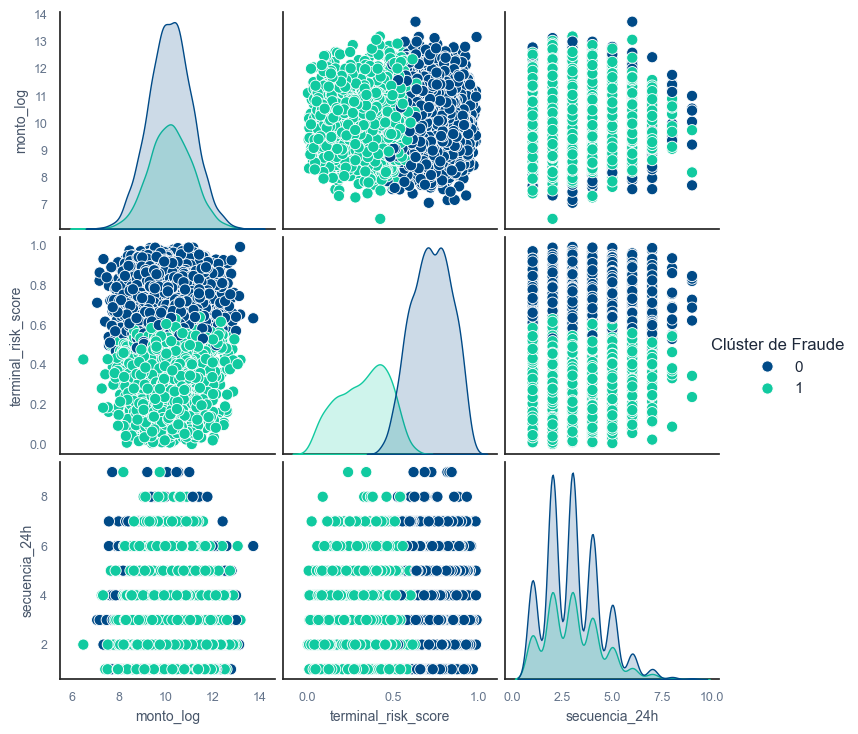

In [48]:
# 1. Estilo base limpio y tipografía corporativa
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["text.color"] = "#1e293b"

# 2. TU PALETA ORIGINAL (Estrictamente guardada)
colores_cluster = ["#004a87", "#11caa0", "#ff823a", "#ff7171", "#bc84ee"]

# 3. Crear el pairplot usando tu paleta exacta
grid = sns.pairplot(
    data=df_fraudes[cols_numericas + ["cluster_fraude"]],
    hue="cluster_fraude",
    palette=colores_cluster[: df_fraudes["cluster_fraude"].nunique()],
    diag_kind="kde",
    plot_kws={
        "alpha": 1.0,
        "s": 65,
    },  # Alpha 1.0 y tamaño 65 para que tus colores resalten bien
    diag_kws={"fill": True, "alpha": 0.2},
)

# 4. Estetizar los textos de los ejes
for ax in grid.axes.flat:
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=10, color="#475569")
        ax.set_ylabel(ax.get_ylabel(), fontsize=10, color="#475569")
        ax.tick_params(colors="#64748b", labelsize=9)
        sns.despine(ax=ax, left=False, bottom=False)

# 5. Formatear la leyenda nativa de Seaborn (Sin duplicados y en su lugar correcto)
grid.legend.set_title("Clúster de Fraude")
grid.legend.get_frame().set_facecolor("white")
grid.legend.get_frame().set_edgecolor("#e2e8f0")
grid.legend.get_frame().set_linewidth(1)

plt.savefig("graficos/cl_feat_num.png")

plt.show()

/var/folders/8q/7djkg4_55rsgfbzr3shf6lsc0000gn/T/ipykernel_47479/2411307684.py:9: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  g = sns.catplot(


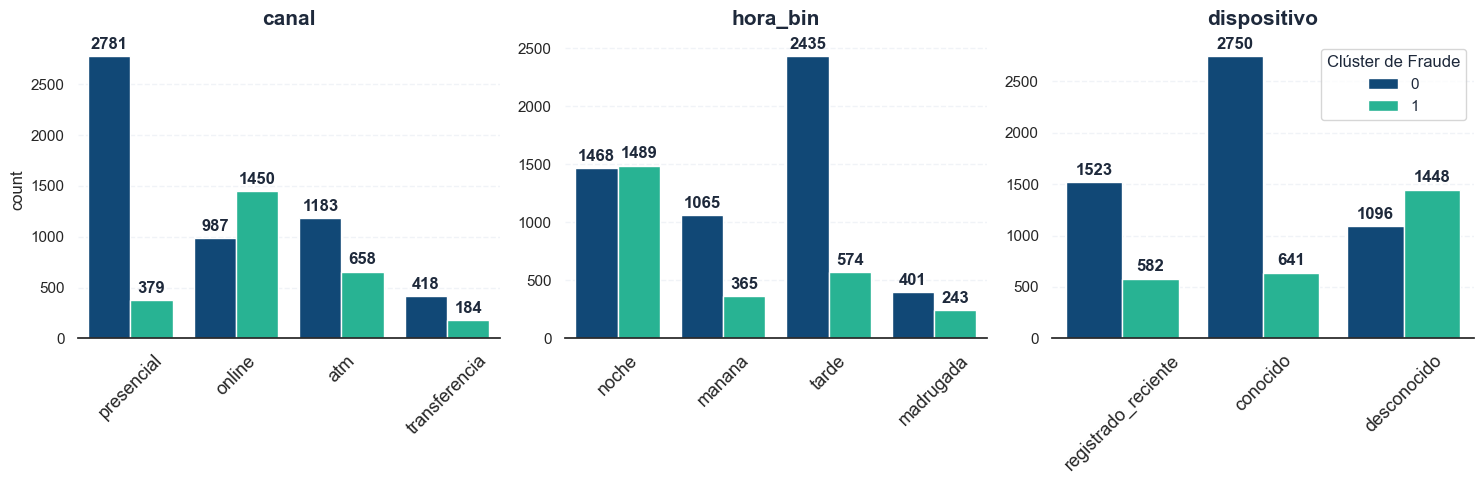

In [47]:
df_melted = pd.melt(
    df_fraudes,
    id_vars=["cluster_fraude"],
    value_vars=cols_categoricas,
    var_name="Variable",
    value_name="Categoria",
)

g = sns.catplot(
    data=df_melted,
    x="Categoria",
    hue="cluster_fraude",
    col="Variable",
    kind="count",
    palette=["#004a87", "#11caa0", "#ff823a", "#ff7171", "#bc84ee"],
    col_wrap=3,
    sharex=False,
    sharey=False,
    legend_out=False,
)

for ax in g.axes.flat:
    if ax is not None:
        ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#e2e8f0")
        ax.set_title(
            ax.get_title().replace("Variable = ", ""),
            fontweight="bold",
            fontsize=15,
            pad=12,
        )
        ax.set_xlabel("", fontsize=13)
        ax.tick_params(axis="x", labelrotation=45, labelsize=13)
        sns.despine(ax=ax, left=True, bottom=False)

        for container in ax.containers:
            ax.bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

g._legend.remove()
plt.legend(title="Clúster de Fraude", loc="upper right")
plt.savefig("graficos/cl_feat_cat.png")
plt.tight_layout()
plt.show()

In [130]:
df_clusters = pd.merge(df_hasta_18[['op_id','mes', 'cluster']], df_fraudes[['op_id','mes', 'cluster_fraude']], on=['op_id', 'mes'], how='left')

In [133]:
pd.crosstab(df_clusters["cluster"], df_clusters["cluster_fraude"])

cluster_fraude,0.0,1.0
cluster,,
0,5,76
1,4,1705
2,5360,890


In [137]:
df_clusters.to_parquet('datos/v6/clustering/clustering_operaciones.parquet')